<a href="https://colab.research.google.com/github/luangz19/App_Flask/blob/main/Modelo1_RandomForestClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 - Importação dos Dados

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amineipad/e-commerce-marketing-and-sales-revenue-prediction")

print("Path to dataset files:", path)

100%|██████████| 1.00M/1.00M [00:00<00:00, 2.09MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/amineipad/e-commerce-marketing-and-sales-revenue-prediction/versions/1


In [2]:
import os

os.listdir(path)

['test.csv', 'train.csv']

In [3]:
import pandas as pd
import seaborn as sns

In [4]:
data_train = pd.read_csv(path + '/train.csv')
data_test = pd.read_csv(path + '/train.csv')

# 2 - Análise Exploratória de dados

In [5]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       18000 non-null  int64  
 1   date                     18000 non-null  object 
 2   region                   18000 non-null  object 
 3   channel                  18000 non-null  object 
 4   product_category         18000 non-null  object 
 5   customer_segment         18000 non-null  object 
 6   ad_spend                 17342 non-null  float64
 7   price                    18000 non-null  float64
 8   discount_rate            17245 non-null  float64
 9   market_reach             17314 non-null  float64
 10  impressions              18000 non-null  int64  
 11  click_through_rate       17287 non-null  float64
 12  competition_index        17293 non-null  float64
 13  seasonality_index        18000 non-null  float64
 14  campaign_duration_days

In [6]:
data_train.head()

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,1,2011-12-05 11:31:00,Nort,Search,General,Standard,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811
1,2,2011-04-27 14:01:00,North,Social Media,General,Premium,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661
2,3,2010-11-09 15:20:00,North,Affiliate,General,Budget,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747
3,4,2010-10-03 15:24:00,North,Affiliate,Storage,Premium,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756
4,5,2011-10-14 09:28:00,North,Search,Lighting,Premium,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924


In [7]:
data_train.columns

Index(['id', 'date', 'region', 'channel', 'product_category',
       'customer_segment', 'ad_spend', 'price', 'discount_rate',
       'market_reach', 'impressions', 'click_through_rate',
       'competition_index', 'seasonality_index', 'campaign_duration_days',
       'customer_lifetime_value', 'sales_revenue'],
      dtype='object')

In [8]:
for i in data_train.columns:
  if data_train[i].dtype == "object":
    print(f"{i}:", data_train[i].unique(), "\n")

date: ['2011-12-05 11:31:00' '2011-04-27 14:01:00' '2010-11-09 15:20:00' ...
 '2011-01-13 13:21:00' '2010-11-09 14:11:00' '2011-11-20 12:11:00'] 

region: ['Nort' 'North' 'north' 'NORTH' 'Central' 'Norht' 'north ' 'East' 'West'
 'South'] 

channel: ['Search' 'Social Media' 'Affiliate' 'Email' 'TV' 'Influencer'
 'Social_Media' 'Socail Media' 'social Media' 'SocialMedia' 'social media'] 

product_category: ['General' 'Storage' 'Lighting' 'Stationery' 'Kitchen' 'Seasonal'] 

customer_segment: ['Standard' 'Premium' 'Budget'] 



In [9]:
print(data_train["region"].value_counts())

region
North      16305
East         374
Norht        248
north        242
NORTH        209
Nort         200
north        199
Central      109
West          77
South         37
Name: count, dtype: int64


In [10]:
# Padronizando a coluna region
def cap(x):
  x = x.capitalize()
  if x == "Norht" or x == "Nort" or x == "North ":
    x = "North"
  return x

data_train["region"] = data_train["region"].apply(cap)
data_train["region"].value_counts()

,count
region,
North,17403
East,374
Central,109
West,77
South,37


In [11]:
print(data_train["channel"].value_counts())

channel
Social Media    4246
Email           3625
Search          3600
Affiliate       2632
TV              1848
Influencer      1806
social Media      55
SocialMedia       50
Social_Media      48
Socail Media      45
social media      45
Name: count, dtype: int64


In [12]:
# Padronizando a coluna channel

def cap2(x):
  palavra = ""
  x = x.capitalize()
  for i in x:
    palavra += i
    if palavra == "Soc":
      x = "Social Media"
      break
      return x
  return x


In [13]:
data_train["channel"] = data_train["channel"].apply(cap2)
data_train["channel"].value_counts()

,count
channel,
Social Media,4489
Email,3625
Search,3600
Affiliate,2632
Tv,1848
Influencer,1806


In [14]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       18000 non-null  int64  
 1   date                     18000 non-null  object 
 2   region                   18000 non-null  object 
 3   channel                  18000 non-null  object 
 4   product_category         18000 non-null  object 
 5   customer_segment         18000 non-null  object 
 6   ad_spend                 17342 non-null  float64
 7   price                    18000 non-null  float64
 8   discount_rate            17245 non-null  float64
 9   market_reach             17314 non-null  float64
 10  impressions              18000 non-null  int64  
 11  click_through_rate       17287 non-null  float64
 12  competition_index        17293 non-null  float64
 13  seasonality_index        18000 non-null  float64
 14  campaign_duration_days

In [15]:
var_num = [i for i in data_train.columns if data_train[i].dtype != "object"]

In [16]:
import matplotlib.pyplot as plt

<Axes: >

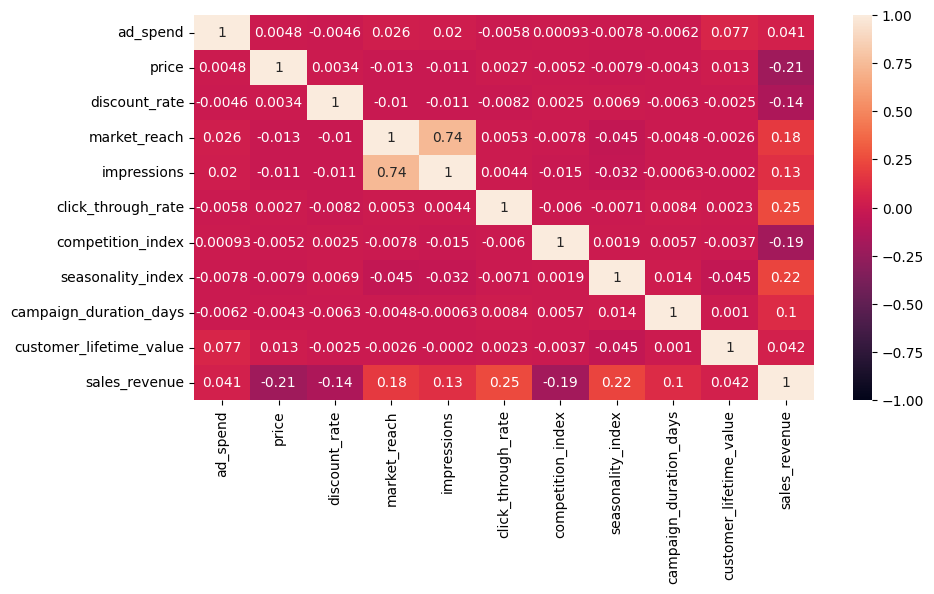

In [17]:
plt.figure(figsize=(10,5))
sns.heatmap(data_train[var_num[1:]].corr(), vmax=1, vmin=-1, annot=True)

In [18]:
data_train.describe()

,id,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
count,18000.000000,17342.000000,18000.000000,17245.000000,17314.000000,18000.000000,17287.000000,17293.000000,18000.000000,16487.000000,17257.000000,18000.000000
mean,9000.500000,44.071797,5.648265,0.230045,321.393323,7257.423889,0.057141,4.004004,-0.014902,35.565597,10317.172008,137.204937
std,5196.296758,190.165450,22.456661,0.149955,244.853653,7600.666112,0.049452,1.994997,0.919343,27.039417,35581.519328,54.961808
min,1.000000,0.180000,0.040000,0.000200,1.000000,-30771.000000,0.000000,0.040000,-1.366025,7.000000,0.550000,0.000000
25%,4500.750000,4.950000,1.250000,0.109500,138.000000,2503.750000,0.020450,2.440000,-1.000000,14.000000,573.110000,100.088209
50%,9000.500000,11.900000,1.950000,0.204000,269.000000,5106.500000,0.043500,3.870000,0.366025,28.000000,1781.440000,129.113361
75%,13500.250000,19.800000,3.750000,0.324900,439.000000,9566.250000,0.079900,5.410000,1.000000,60.000000,5502.780000,164.688454
max,18000.000000,4254.500000,295.000000,0.600000,1490.000000,173986.000000,0.435700,9.650000,1.366025,90.000000,543228.100000,684.320270


# 3 - Tratamento de dados, Seleção e Treinamneto de Modelos

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor

In [20]:
# Colunas dos dados faltantes do tipo object
for i in data_train.columns:
  if data_train[i].dtype == "object":
    print(f"{i}:", data_train[i].isna().sum())

date: 0
region: 0
channel: 0
product_category: 0
customer_segment: 0


In [21]:
# Colunas dos dados faltantes do tipo númerica
for i in data_train.columns:
  if data_train[i].dtype != "object":
    print(f"{i}:", data_train[i].isna().sum())

id: 0
ad_spend: 658
price: 0
discount_rate: 755
market_reach: 686
impressions: 0
click_through_rate: 713
competition_index: 707
seasonality_index: 0
campaign_duration_days: 1513
customer_lifetime_value: 743
sales_revenue: 0


In [22]:
# Variaveis Categóricas e númericas
var_cat = ['region', 'channel', 'product_category']
var_cat_ord = ['customer_segment']
var_num_nan = ['ad_spend', 'discount_rate','market_reach', 'click_through_rate',
               'competition_index', 'campaign_duration_days', 'customer_lifetime_value',]

In [23]:
tranform_col = make_column_transformer(
    (SimpleImputer(strategy="median"), var_num_nan),
    ("passthrough", ["price", "impressions", "seasonality_index"]),
    (OneHotEncoder(handle_unknown="ignore"), var_cat_ord),
    (OneHotEncoder(handle_unknown="ignore"), var_cat)
)

In [24]:
model1 = make_pipeline(tranform_col, RandomForestRegressor(random_state=42))
model2 = make_pipeline(tranform_col, GradientBoostingRegressor(random_state=42))
model3 = make_pipeline(tranform_col, AdaBoostRegressor(random_state=42))

In [25]:
X, y = data_train.drop(columns=["id", "date", "sales_revenue"]), data_train["sales_revenue"]

In [26]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)

In [27]:
model1.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('simpleimputer',
                                                  SimpleImputer(strategy='median'),
                                                  ['ad_spend', 'discount_rate',
                                                   'market_reach',
                                                   'click_through_rate',
                                                   'competition_index',
                                                   'campaign_duration_days',
                                                   'customer_lifetime_value']),
                                                 ('passthrough', 'passthrough',
                                                  ['price', 'impressions',
                                                   'seasonality_index']),
                                                 ('onehotencoder-1',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['customer_segment']),
                                                 ('onehotencoder-2',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['region', 'channel',
                                                   'product_category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [28]:
model2.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('simpleimputer',
                                                  SimpleImputer(strategy='median'),
                                                  ['ad_spend', 'discount_rate',
                                                   'market_reach',
                                                   'click_through_rate',
                                                   'competition_index',
                                                   'campaign_duration_days',
                                                   'customer_lifetime_value']),
                                                 ('passthrough', 'passthrough',
                                                  ['price', 'impressions',
                                                   'seasonality_index']),
                                                 ('onehotencoder-1',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['customer_segment']),
                                                 ('onehotencoder-2',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['region', 'channel',
                                                   'product_category'])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(random_state=42))])

In [29]:
model3.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('simpleimputer',
                                                  SimpleImputer(strategy='median'),
                                                  ['ad_spend', 'discount_rate',
                                                   'market_reach',
                                                   'click_through_rate',
                                                   'competition_index',
                                                   'campaign_duration_days',
                                                   'customer_lifetime_value']),
                                                 ('passthrough', 'passthrough',
                                                  ['price', 'impressions',
                                                   'seasonality_index']),
                                                 ('onehotencoder-1',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['customer_segment']),
                                                 ('onehotencoder-2',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['region', 'channel',
                                                   'product_category'])])),
                ('adaboostregressor', AdaBoostRegressor(random_state=42))])

In [30]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, mean_squared_error

In [31]:
for model in [model1, model2, model3]:
  print("R2 - Treino:", r2_score(y_train, model.predict(X_train)), "Val:", r2_score(y_val, model.predict(X_val)))
  print("MSE - Treino:", mean_squared_error(y_train, model.predict(X_train)), "Val:", mean_squared_error(y_val, model.predict(X_val)))
  print("MAE - Treino:", mean_absolute_error(y_train, model.predict(X_train)),  "Val:",  mean_absolute_error(y_val, model.predict(X_val)))
  print("RMSE - Treino:", root_mean_squared_error(y_train, model.predict(X_train)),  "Val:", root_mean_squared_error(y_val, model.predict(X_val)), "\n")

R2 - Treino: 0.9881446888449773 Val: 0.9186657173299096
MSE - Treino: 35.510686528720925 Val: 253.68058023324102
MAE - Treino: 4.471173115892742 Val: 12.041210826431614
RMSE - Treino: 5.959084369995186 Val: 15.927353208654633 

R2 - Treino: 0.9486690219379861 Val: 0.9396981900040213
MSE - Treino: 153.753726691565 Val: 188.08056881676941
MAE - Treino: 9.356468125314 Val: 10.093151921444987
RMSE - Treino: 12.399747041434555 Val: 13.714246928532729 

R2 - Treino: 0.7467210699932998 Val: 0.742690986273058
MSE - Treino: 758.6564848605632 Val: 802.5435002145459
MAE - Treino: 22.253158713457488 Val: 22.65361687683125
RMSE - Treino: 27.54371951753363 Val: 28.329198721717244 



In [32]:
from sklearn.model_selection import RandomizedSearchCV

In [33]:
pipe = make_pipeline(tranform_col, RandomForestRegressor(random_state=42))
print(pipe.get_params().keys())

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'columntransformer', 'randomforestregressor', 'columntransformer__force_int_remainder_cols', 'columntransformer__n_jobs', 'columntransformer__remainder', 'columntransformer__sparse_threshold', 'columntransformer__transformer_weights', 'columntransformer__transformers', 'columntransformer__verbose', 'columntransformer__verbose_feature_names_out', 'columntransformer__simpleimputer', 'columntransformer__passthrough', 'columntransformer__onehotencoder-1', 'columntransformer__onehotencoder-2', 'columntransformer__simpleimputer__add_indicator', 'columntransformer__simpleimputer__copy', 'columntransformer__simpleimputer__fill_value', 'columntransformer__simpleimputer__keep_empty_features', 'columntransformer__simpleimputer__missing_values', 'columntransformer__simpleimputer__strategy', 'columntransformer__onehotencoder-1__categories', 'columntransformer__onehotencoder-1__drop', 'columntransformer__onehotencoder-1__dtype', 'columntran

In [34]:
param_dist = {
    "randomforestregressor__n_estimators": [100, 200, 300, 500],
    "randomforestregressor__max_depth": [5, 10, 20, None],
    "randomforestregressor__min_samples_split": [2, 5, 10]
}


In [35]:
Search_Model1 = RandomizedSearchCV(
    make_pipeline(tranform_col, StandardScaler(), RandomForestRegressor(random_state=42)),
    param_distributions=param_dist,
    n_iter=10,   # controla custo
    cv=3,        # menos folds → mais rápido
    random_state=42,
    n_jobs=-1    # usa todos os núcleos
)

In [36]:
Search_Model1.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('simpleimputer',
                                                                               SimpleImputer(strategy='median'),
                                                                               ['ad_spend',
                                                                                'discount_rate',
                                                                                'market_reach',
                                                                                'click_through_rate',
                                                                                'competition_index',
                                                                                'campaign_duration_days',
                                                                                'customer_lifetime_value']),
                                                                              ('passthrough',
                                                                               'passthrough',
                                                                               ['price',
                                                                                'impressions',
                                                                                'seasona...
                                                                               ['region',
                                                                                'channel',
                                                                                'product_category'])])),
                                             ('standardscaler',
                                              StandardScaler()),
                                             ('randomforestregressor',
                                              RandomForestRegressor(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'randomforestregressor__max_depth': [5,
                                                                             10,
                                                                             20,
                                                                             None],
                                        'randomforestregressor__min_samples_split': [2,
                                                                                     5,
                                                                                     10],
                                        'randomforestregressor__n_estimators': [100,
                                                                                200,
                                                                                300,
                                                                                500]},
                   random_state=42)

In [37]:
Model1 = Search_Model1.best_estimator_

In [38]:
param_dist2 = {
    "gradientboostingregressor__n_estimators": [100, 200, 300],
    "gradientboostingregressor__learning_rate": [0.05, 0.1],
    "gradientboostingregressor__max_depth": [3, 5],
    "gradientboostingregressor__subsample": [0.8, 1.0]
}

In [39]:
Search_Model2 = RandomizedSearchCV(
    make_pipeline(tranform_col, StandardScaler(), GradientBoostingRegressor(random_state=42)),
    param_distributions=param_dist2,
    n_iter=10,
    cv=3,
    random_state=42,
    n_jobs=-1
)

In [40]:
Search_Model2.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('simpleimputer',
                                                                               SimpleImputer(strategy='median'),
                                                                               ['ad_spend',
                                                                                'discount_rate',
                                                                                'market_reach',
                                                                                'click_through_rate',
                                                                                'competition_index',
                                                                                'campaign_duration_days',
                                                                                'customer_lifetime_value']),
                                                                              ('passthrough',
                                                                               'passthrough',
                                                                               ['price',
                                                                                'impressions',
                                                                                'seasona...
                                             ('standardscaler',
                                              StandardScaler()),
                                             ('gradientboostingregressor',
                                              GradientBoostingRegressor(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'gradientboostingregressor__learning_rate': [0.05,
                                                                                     0.1],
                                        'gradientboostingregressor__max_depth': [3,
                                                                                 5],
                                        'gradientboostingregressor__n_estimators': [100,
                                                                                    200,
                                                                                    300],
                                        'gradientboostingregressor__subsample': [0.8,
                                                                                 1.0]},
                   random_state=42)

In [41]:
Model2 = Search_Model2.best_estimator_

In [42]:
param_dist3 = {
    "adaboostregressor__n_estimators": [50, 100, 200, 300],
    "adaboostregressor__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
    "adaboostregressor__loss": ["linear", "square", "exponential"]
}

In [43]:
Search_Model3 = RandomizedSearchCV(
    make_pipeline(tranform_col, StandardScaler(), AdaBoostRegressor(random_state=42)),
    param_distributions=param_dist3,
    n_iter=10,
    cv=3,
    random_state=42,
    n_jobs=-1
)

In [44]:
Search_Model3.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('simpleimputer',
                                                                               SimpleImputer(strategy='median'),
                                                                               ['ad_spend',
                                                                                'discount_rate',
                                                                                'market_reach',
                                                                                'click_through_rate',
                                                                                'competition_index',
                                                                                'campaign_duration_days',
                                                                                'customer_lifetime_value']),
                                                                              ('passthrough',
                                                                               'passthrough',
                                                                               ['price',
                                                                                'impressions',
                                                                                'seasona...
                                                                               ['region',
                                                                                'channel',
                                                                                'product_category'])])),
                                             ('standardscaler',
                                              StandardScaler()),
                                             ('adaboostregressor',
                                              AdaBoostRegressor(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'adaboostregressor__learning_rate': [0.01,
                                                                             0.05,
                                                                             0.1,
                                                                             0.5,
                                                                             1.0],
                                        'adaboostregressor__loss': ['linear',
                                                                    'square',
                                                                    'exponential'],
                                        'adaboostregressor__n_estimators': [50,
                                                                            100,
                                                                            200,
                                                                            300]},
                   random_state=42)

In [45]:
Model3 = Search_Model3.best_estimator_

In [46]:
for model in [Model1, Model2, Model3]:
  print("R2 - Treino:", r2_score(y_train, model.predict(X_train)), "Val:", r2_score(y_val, model.predict(X_val)))
  print("MSE - Treino:", mean_squared_error(y_train, model.predict(X_train)), "Val:", mean_squared_error(y_val, model.predict(X_val)))
  print("MAE - Treino:", mean_absolute_error(y_train, model.predict(X_train)),  "Val:",  mean_absolute_error(y_val, model.predict(X_val)))
  print("RMSE - Treino:", root_mean_squared_error(y_train, model.predict(X_train)),  "Val:", root_mean_squared_error(y_val, model.predict(X_val)), "\n")

R2 - Treino: 0.9883087774810032 Val: 0.9194007451794427
MSE - Treino: 35.01918529010735 Val: 251.38803783616265
MAE - Treino: 4.465849767162479 Val: 12.014115283159299
RMSE - Treino: 5.917701013916414 Val: 15.855221153808062 

R2 - Treino: 0.9786866130988521 Val: 0.9713276283536421
MSE - Treino: 63.84083818764678 Val: 89.42875792505119
MAE - Treino: 6.334748129072771 Val: 7.116039536517021
RMSE - Treino: 7.990046194337476 Val: 9.4566779539673 

R2 - Treino: 0.7901649320257996 Val: 0.7837607839478329
MSE - Treino: 628.5273515075769 Val: 674.4473301596769
MAE - Treino: 20.044043354952223 Val: 20.54933183700944
RMSE - Treino: 25.070447772378873 Val: 25.970123799467665 



# 4 - Testando o melhor modelo no dataset de teste

In [62]:
X_test, y_test = data_test.drop(columns=["id", "date", "sales_revenue"]), data_test["sales_revenue"]

In [65]:
y_predict =  Model2.predict(X_test)

In [67]:
print("R2 - Teste:", r2_score(y_test, y_predict))
print("MSE - Teste:", mean_squared_error(y_test, y_predict))
print("MAE - Teste:", mean_absolute_error(y_test, y_predict))
print("RMSE - Teste:", root_mean_squared_error(y_test, y_predict))

R2 - Teste: 0.9545372956711446
MSE - Teste: 137.32612432383402
MAE - Teste: 8.38149023351857
RMSE - Teste: 11.71862297046176


In [75]:
print(y_predict.mean(), y_predict.std())
print(y_test.mean(), y_test.std())

139.04735341258754 53.785440175872374
137.20493699081942 54.961808269187145


<Axes: xlabel='sales_revenue', ylabel='Count'>

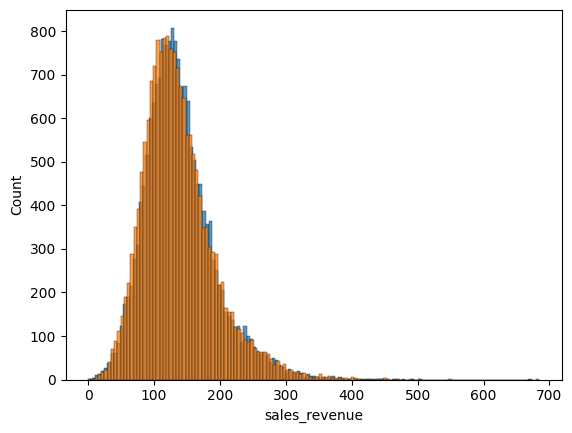

In [72]:
sns.histplot(y_predict)
sns.histplot(y_test)